In [8]:
import os, sys
from pathlib import Path
import pandas as pd
HERE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
LEVEL1 = HERE.parent

if str(LEVEL1) not in sys.path:
    sys.path.insert(0, str(LEVEL1))
    
from argparse import ArgumentParser
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import torch
import math
import numpy as np

from data.synthetic import sim_data
from estimation.ecm import ECM_update
from models.dps import DPS
from training.early_stopping import EarlyStopping
from training.trainer import *
from training.loss import spline_penalty_loss
from data.dataset import Dataset

import itertools


import matplotlib.pyplot as plt

def create_loaders(X_train, y_train, X_val, y_val, batch_size=None):
    bs = batch_size if batch_size else len(X_train)
    
    train_ds = TensorDataset(X_train, y_train)
    val_ds = TensorDataset(X_val, y_val)
    
    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=len(X_val), shuffle=False) # Val 通常不需要 shuffle
    return train_loader, val_loader

def compute_GCV(model, X_in, X, y):
    XTX = torch.matmul(X, X.T)
    batch = X.size()[1]
    A = XTX
    try:
        A_inv = torch.inverse(A)
        
    except RuntimeError:
        # 如果 A 接近奇異矩陣，加一點 jitter (通常 lambda > 0 就不會發生)
        jitter = 1e-6 * torch.eye(A.shape[0], device=A.device)
        A_inv = torch.inverse(A + jitter)
    
    M = torch.matmul(A_inv, XTX)
    dof = torch.trace(M)
    with torch.no_grad():
        DPSy = model(X_in)
        GCV = float((criterion(y, DPSy)/(1-dof/batch)**2).item()) if (dof<batch) else float(criterion(y, DPSy).item())

    return GCV

if __name__ == "__main__":
    
    ntrain = 200
    nval = 200
    ntest = 1000
    Dtype = 'A'
    ndim = 2
    learning_rate = 1e-1
    ndf = 20
    nk = 10
    nbl = 1   
    Fout = 1
    data = {}
    
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    device = "cpu"
    criterion = torch.nn.MSELoss(reduction='mean')
    
    ## Storing parameter ##
    result = {}
    Lambdalist = {}
    Bres = np.zeros((ndf, 1))
    Pres = np.zeros((ndf, 1))
    Iterlist = np.zeros((ndf, 1))
    for d in range(ndf):
    
        ####################
        # Data Preparation #
        ####################
        
        torch.manual_seed(d)
        X_train, y_train = sim_data(ntrain, ndim, Dtype)
        X_val, y_val = sim_data(nval, ndim, Dtype)
        X_test, y_test = sim_data(ntest, ndim, Dtype)
        epstrain = torch.normal(0, torch.var(y_train)*0.01, size=y_train.size())
        epsval = torch.normal(0, torch.var(y_val)*0.01, size=y_val.size())
        epstest = torch.normal(0, torch.var(y_test)*0.01, size=y_test.size())
        
        y_train, y_test, y_val = y_train + epstrain, y_test + epstest, y_val + epsval
        data[str(d+1)] = {'TrainX': X_train, 'Trainy': y_train, 'TestX': X_test, 'Testy': y_test, 'ValX': X_val, 'Valy': y_val}
        
        
        train_loader, val_loader = create_loaders(X_train, y_train, X_val, y_val)
        
        _config = {0: [10], 1: [10, 10], 2: [10, 10, 10], 3: [15], 4: [15, 15], 5: [15, 15, 15], 6: [20], 7: [20, 20], 8:[20, 20, 20]}
        _result = torch.zeros(len(_config))
        
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        device = "cpu"
        criterion = torch.nn.MSELoss(reduction='mean')
        
        ndim = X_train.size()[1]
        Fout = 1
        nk = 10
        
        for key, value in _config.items():
        
        
            DeepBS = DPS(input_dim = ndim, degree = 3, num_knots = nk, num_neurons = value, num_bsl = len(value), dropout = 0.0, output_dim = Fout, knots_place = 'quantile', bias = True).to(device)
            
            optimizer = torch.optim.Adam(DeepBS.parameters(), lr=learning_rate)
            save_path_bs = f"./logs/best_DBS_model_{key}.pt"
            early_stop = EarlyStopping(patience=50, verbose=False, delta=1e-3, path=save_path_bs)
        
            trainer = Trainer(DeepBS, optimizer, criterion, device, early_stopping=early_stop)
            trainer.fit(train_loader, val_loader, epochs=10000)
            
            with torch.no_grad():
                DeepBS.load_state_dict(torch.load(save_path_bs, weights_only=True))
                # Hook
                activations = {}
                def get_last_layer_hook(module, input, output):
                    activations['last_layer'] = output.detach()
                handle = DeepBS.Spline_block.register_forward_hook(get_last_layer_hook)
                output = DeepBS(X_train)
                last_neurons = activations['last_layer']
                handle.remove()
        
                # GCV Calculation
                _result[key] = compute_GCV(DeepBS, X_train, last_neurons, y_train)
                
        min_idx = torch.argmin(_result).item()
        min_archi = _config[min_idx]
        neuron_options = [min_archi[0] - 5, min_archi[0], min_archi[0] + 5]
        
        opt_nbl = len(min_archi)
        combinations = list(itertools.product(neuron_options, repeat=opt_nbl))
        dps_model_config = {i + 1: list(combo) for i, combo in enumerate(combinations)}
        
        if min_archi == [15,15]:
            print('found')
            break

Epochs:   2%|▏         | 241/10000 [00:09<06:29, 25.08it/s, Train=0.0401, Val=0.3502]


Early stopping triggered at epoch 241


Epochs:   2%|▏         | 197/10000 [00:08<06:57, 23.48it/s, Train=0.0116, Val=0.0252]


Early stopping triggered at epoch 197


Epochs:   1%|          | 120/10000 [00:10<13:56, 11.82it/s, Train=0.0145, Val=1.0247]


...

Early stopping triggered at epoch 195


Epochs:   2%|▏         | 221/10000 [00:13<09:54, 16.45it/s, Train=0.0081, Val=0.1536]


Early stopping triggered at epoch 221


Epochs:   3%|▎         | 258/10000 [00:14<09:08, 17.77it/s, Train=0.0066, Val=0.0903]


Early stopping triggered at epoch 258
found


### Model Selection

In [9]:
for i, hidden_config in dps_model_config.items():
    
    DeepBS = DPS(input_dim = ndim, degree = 3, num_knots = nk, num_neurons = hidden_config, num_bsl = len(hidden_config), dropout = 0.0, output_dim = Fout, knots_place = 'quantile', bias = True).to(device)
    optimizer = torch.optim.Adam(DeepBS.parameters(), lr=learning_rate)
    save_path_bs = f"best_DBS_model_{i}.pt"
    early_stop = EarlyStopping(patience=50, verbose=False, delta=1e-3, path=save_path_bs)
    trainer = Trainer(DeepBS, optimizer, criterion, device, early_stopping=early_stop)
    trainer.fit(train_loader, val_loader, epochs=10000)

Epochs:   2%|▏         | 210/10000 [00:09<07:19, 22.29it/s, Train=0.0122, Val=0.0390]


Early stopping triggered at epoch 210


Epochs:   2%|▏         | 205/10000 [00:06<05:27, 29.88it/s, Train=0.0091, Val=0.0248]


Early stopping triggered at epoch 205


Epochs:   2%|▏         | 188/10000 [00:09<08:06, 20.15it/s, Train=0.0092, Val=0.0381]


...

Early stopping triggered at epoch 189


Epochs:   2%|▏         | 197/10000 [00:12<10:42, 15.26it/s, Train=0.0072, Val=0.0351]


Early stopping triggered at epoch 197


Epochs:   2%|▏         | 236/10000 [00:10<07:12, 22.59it/s, Train=0.0090, Val=0.0595]

Early stopping triggered at epoch 236


### Model Training

In [11]:
MSPE_array = torch.zeros((3, 3))

with torch.no_grad():
    cnt = 1
    for i in range(3):
        for j in range(3):
            save_path_bs = 'best_DBS_model_'+str(cnt)+'.pt'
            DeepBS = DPS(input_dim = ndim, degree = 3, num_knots = nk, num_neurons = dps_model_config[cnt], num_bsl = len(hidden_config), dropout = 0.0, output_dim = Fout, knots_place = 'uniform', bias = True).to(device)
            DeepBS.load_state_dict(torch.load(save_path_bs, weights_only=True))

            '''
            # Hook
            activations = {}
            def get_last_layer_hook(module, input, output):
                activations['last_layer'] = output.detach()
            handle = DeepBS.Spline_block.register_forward_hook(get_last_layer_hook)
            output = DeepBS(X_train)
            last_neurons = activations['last_layer']
            handle.remove()
            
            # GCV Calculation
            GCV_array[i, j] = compute_GCV(DeepBS, X_train, last_neurons, y_train)
            '''
            with torch.no_grad():
                DeepBS.eval()
                MSPE_array[i, j] = criterion(DeepBS(X_test), y_test)
                cnt += 1
                

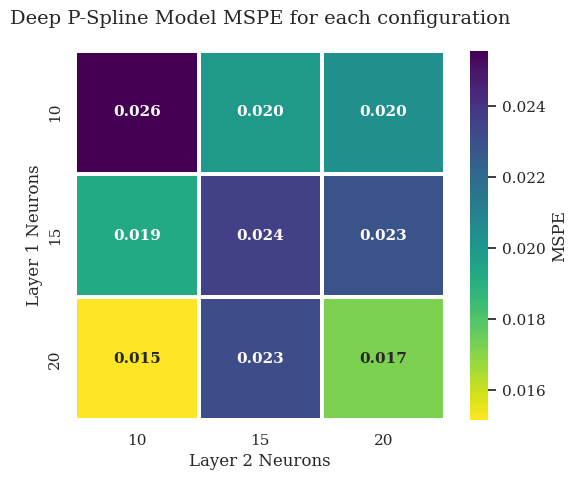

In [17]:
import seaborn as sns
sns.set(font="serif") 

v_min = MSPE_array.min()
v_max = MSPE_array.max()

z_values = MSPE_array
df = pd.DataFrame(z_values, index=neuron_options, columns=neuron_options)

min_idx = np.unravel_index(np.argmin(df.values, axis=None), df.shape)

sns.heatmap(df, 
            annot=True, 
            fmt=".3f", 
            cmap="viridis_r", 
            linewidths=1.5,
            square=True,            
         
            vmin=v_min, vmax=v_max, 
            cbar_kws={'label': 'MSPE'} if i == 2 else {},
            annot_kws={"size": 11, "weight": "bold"})

plt.Rectangle((min_idx[1], min_idx[0]), 1, 1, fill=False, edgecolor='red', lw=3)


plt.xlabel('Layer 2 Neurons', fontsize=12)
plt.ylabel('Layer 1 Neurons', fontsize=12)

plt.title('Deep P-Spline Model MSPE for each configuration', fontsize=14, y=1.05)

plt.savefig('dps_model_selection_pro.png', dpi=600, bbox_inches='tight')
plt.show()